In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# lambda x: output ở input số

In [5]:
df = pd.read_csv('../../data/raw/housing.csv')

In [6]:
# 01 Overview
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [7]:
#02 Kiểm tra lỗi nhập liệu và trùng lập
# pd.to_numeric(df['longitude'], errors='coerce').isna().sum()
# pd.to_numeric(df['housing_median_age'], errors='coerce').isna().sum()
# pd.to_numeric(df['total_rooms'], errors='coerce').isna().sum()
# pd.to_numeric(df['total_bedrooms'], errors='coerce').isna().sum()
# pd.to_numeric(df['population'], errors='coerce').isna().sum()
# pd.to_numeric(df['households'], errors='coerce').isna().sum()
# pd.to_numeric(df['median_income'], errors='coerce').isna().sum()
# pd.to_numeric(df['median_house_value'], errors='coerce').isna().sum()

# invalid_count = pd.to_numeric(df['ocean_proximity'], errors='coerce').isna().sum()
# len(df['ocean_proximity']) - invalid_count

# df.duplicated().sum()

In [8]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [9]:
# 02 Missing data
(df.isna().sum() / len(df))*100

longitude             0.000000
latitude              0.000000
housing_median_age    0.000000
total_rooms           0.000000
total_bedrooms        1.002907
population            0.000000
households            0.000000
median_income         0.000000
median_house_value    0.000000
ocean_proximity       0.000000
dtype: float64

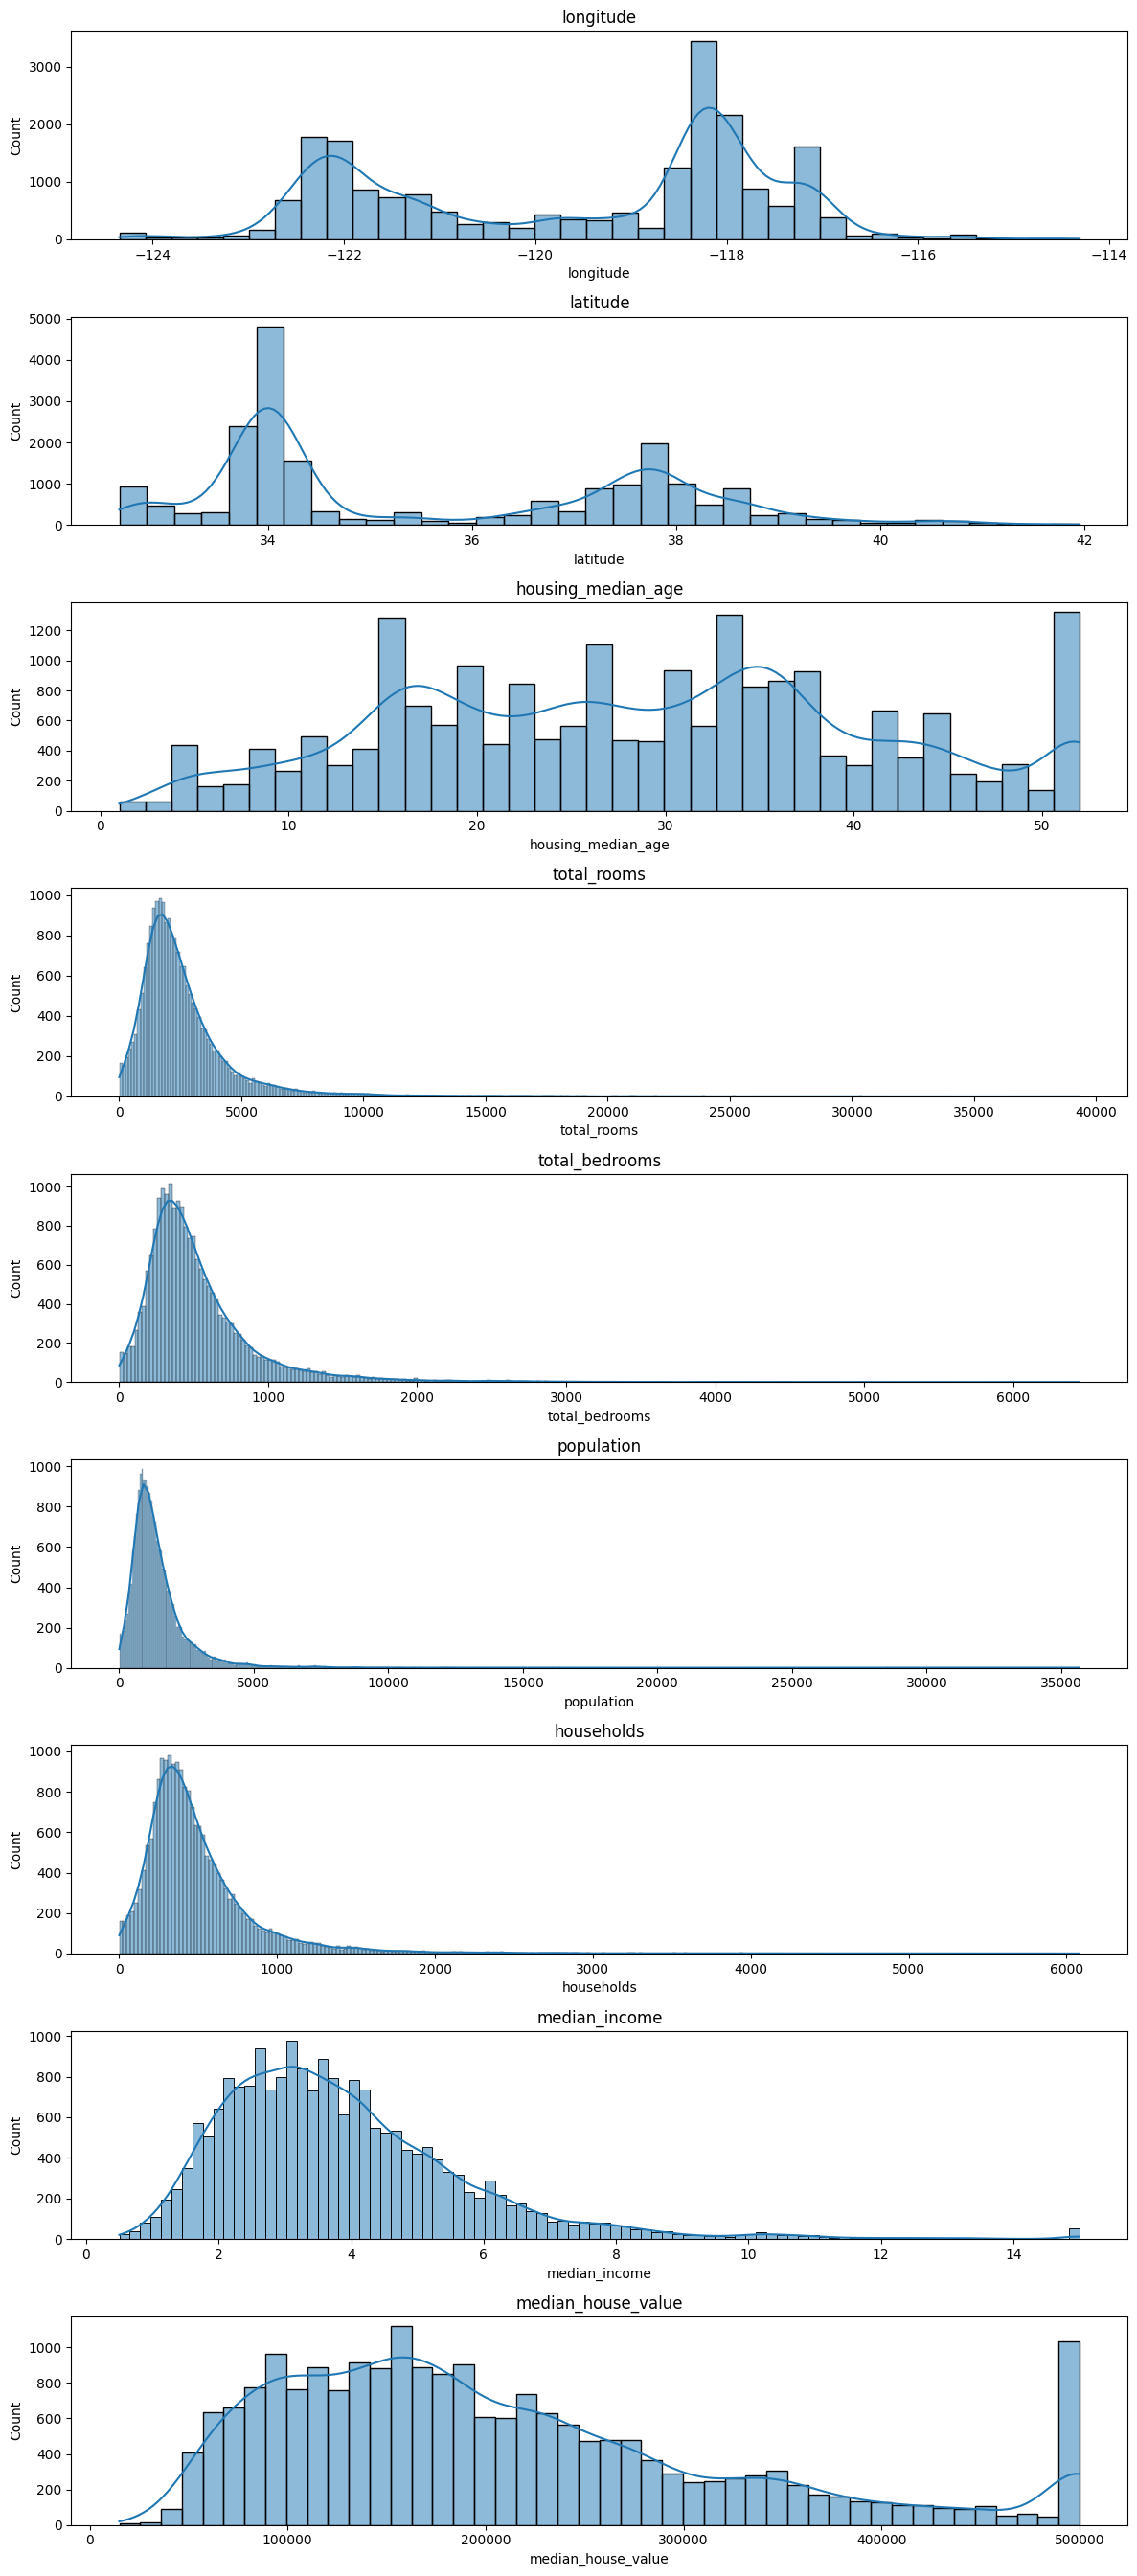

In [10]:
# 3. Phân phối + skew
# Kiểm tra nhập sai

# df.hist(figsize=(15, 15), bins=50)
# Kích thước mỗi bảng

# Đọc thêm (Code cũ cho từng dòng)
# sns.histplot(df['longitude'],bins=50, kde=True)
# Số nhà ở các giá theo X
# 50 Khoảng giá trị, càng cao càng chi tiết
cols = df.columns[0:-1]
n = len(cols)

fig, axes = plt.subplots(n, 1, figsize=(12, 3*n))

for i, col in enumerate(cols):
    sns.histplot(df[col], kde = True, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

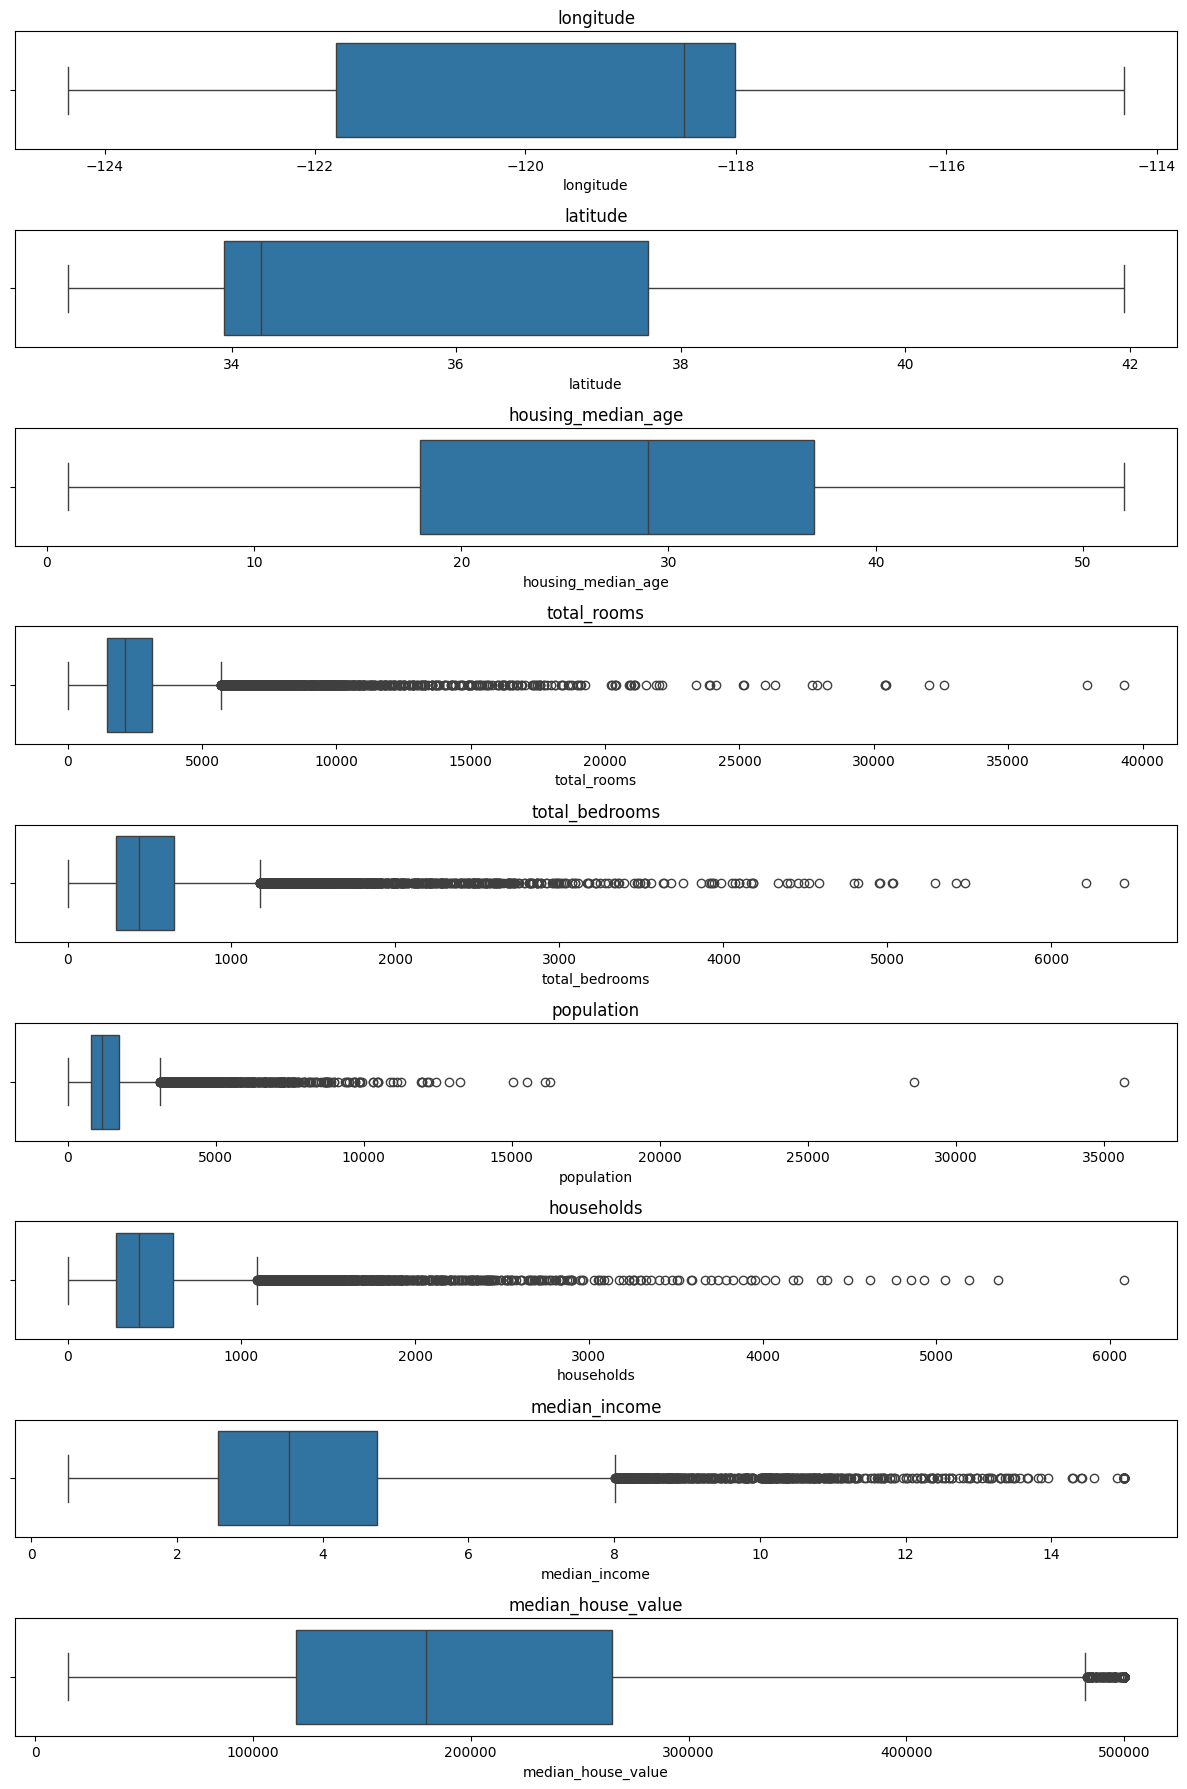

In [11]:


# Tạo figure với n subplot theo chiều dọc
fig, axes = plt.subplots(nrows=n, figsize=(12, 2*n), sharex=False)  # sharex=False để mỗi cột scale riêng

for i, col in enumerate(cols):
    sns.boxplot(x=df[col], ax=axes[i], orient='h')
    axes[i].set_title(col)
    
# i: mặc định index
# i chạy đến len(cols) - 1 và tự dừng — không bao giờ chạy quá giới hạn.
# axis khác axes, 1 trục, nhiều trục => 1 khung, ô biểu đồ
# orient định hướng gồm h:ori ngang, v:ert dọc

plt.tight_layout()
plt.show()
# plt.close('all')
# --- age, t

<Axes: >

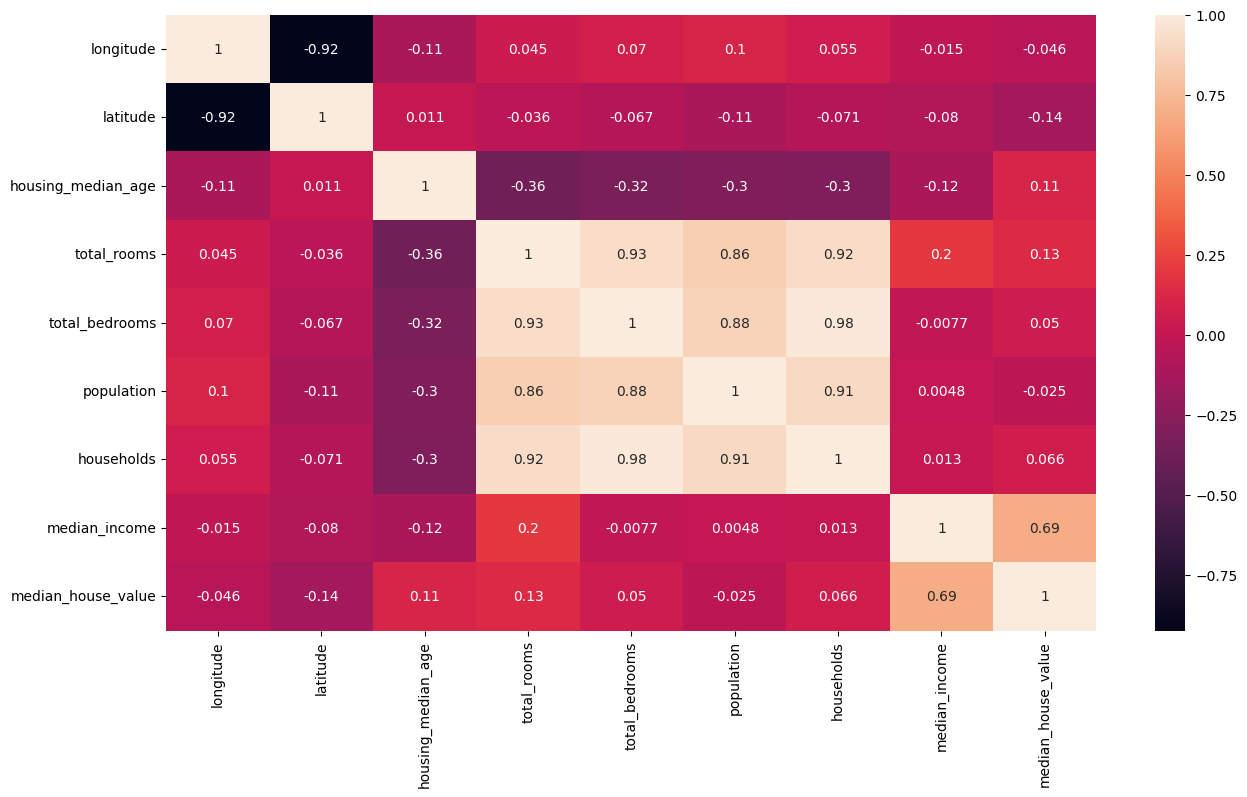

In [12]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.iloc[:,:-1].corr(), annot=True)

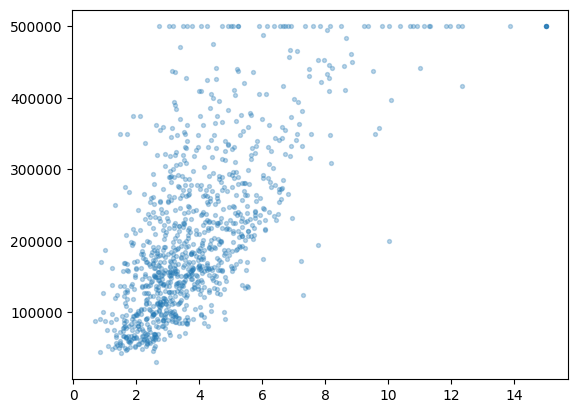

In [59]:
plt.scatter(sample['median_income'], sample['median_house_value'], alpha=0.3, s=8)
plt.show()

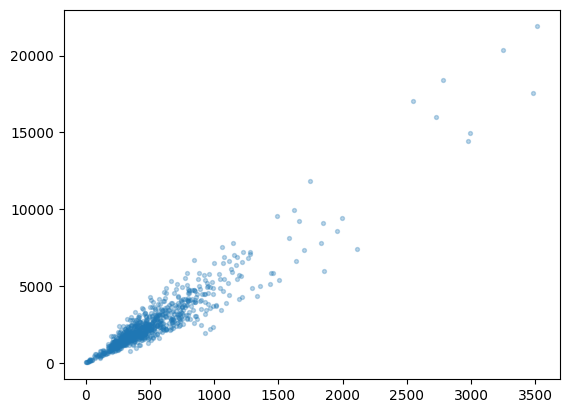

In [60]:
plt.scatter(sample['total_bedrooms'], sample['total_rooms'], alpha=0.3, s=8)
plt.show()

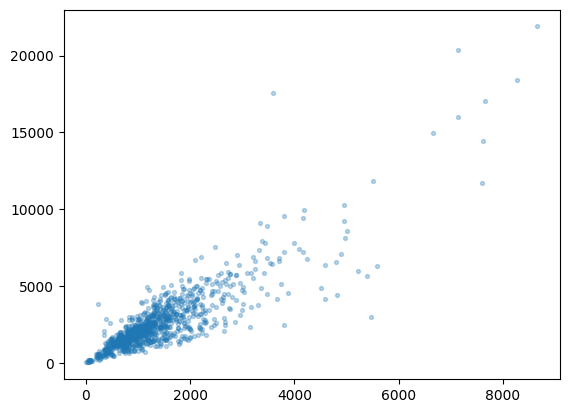

In [61]:
plt.scatter(sample['population'], sample['total_rooms'], alpha=0.3, s=8)
plt.show()

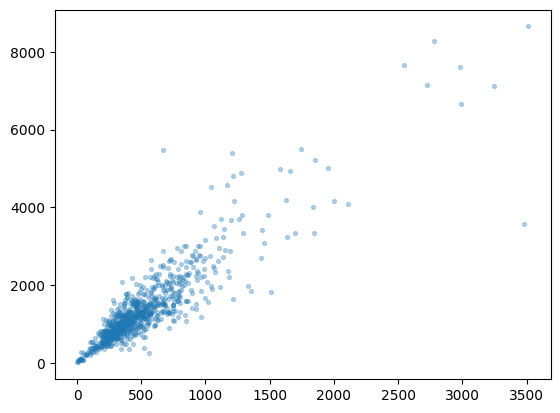

In [62]:
plt.scatter(sample['total_bedrooms'], sample['population'], alpha=0.3, s=8)
plt.show()

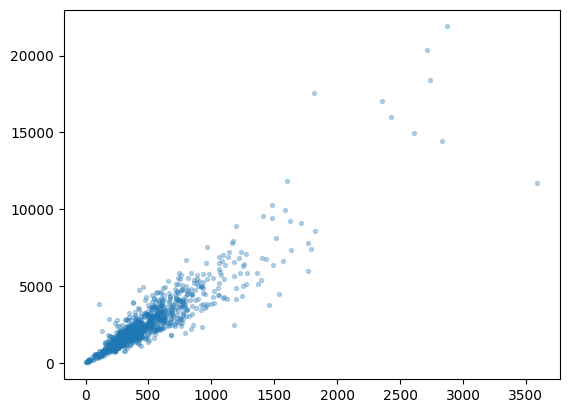

In [63]:
plt.scatter(sample['households'], sample['total_rooms'], alpha=0.3, s=8)
plt.show()

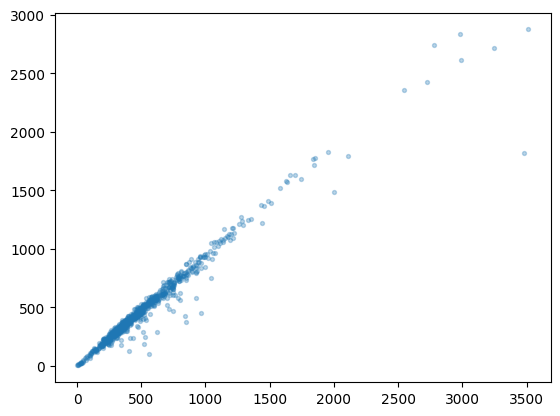

In [64]:
plt.scatter(sample['total_bedrooms'], sample['households'], alpha=0.3, s=8)
plt.show()

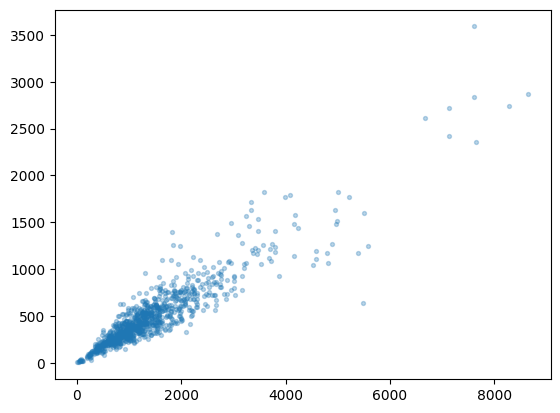

In [66]:
plt.scatter(sample['population'], sample['households'], alpha=0.3, s=8)
plt.show()